# Split Step Distribution Comparison for Task 584

This notebook compares split-step distributions between:

- ground truth: `gallery/([cb7a0e9e733d26ffc00e7f6c9cc0f879,[1,128,128,32],[1,1,32,16],[1,1,1,16],[1,128,128,16]],cuda).json`
- generated: `gallery/constrained_gen/584_([cb7a0e9e733d26ffc00e7f6c9cc0f879,[1,128,128,32],[1,1,32,16],[1,1,1,16],[1,128,128,16]],cuda).json`

It reports per-split-step support size, top families, and distribution distance metrics.

In [14]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from tvm.auto_scheduler import RecordReader

GROUND_TRUTH_PATH = '/root/work/tvm-ansor/gallery/([cb7a0e9e733d26ffc00e7f6c9cc0f879,[1,128,128,32],[1,1,32,16],[1,1,1,16],[1,128,128,16]],cuda).json'
GENERATED_PATH = '/root/work/tvm-ansor/gallery/constrained_gen/584_([cb7a0e9e733d26ffc00e7f6c9cc0f879,[1,128,128,32],[1,1,32,16],[1,1,1,16],[1,128,128,16]],cuda).json'

print(GROUND_TRUTH_PATH)
print(GENERATED_PATH)

/root/work/tvm-ansor/gallery/([cb7a0e9e733d26ffc00e7f6c9cc0f879,[1,128,128,32],[1,1,32,16],[1,1,1,16],[1,128,128,16]],cuda).json
/root/work/tvm-ansor/gallery/constrained_gen/584_([cb7a0e9e733d26ffc00e7f6c9cc0f879,[1,128,128,32],[1,1,32,16],[1,1,1,16],[1,128,128,16]],cuda).json


In [15]:
def load_split_step_counters(path):
    inputs, results = RecordReader(str(path)).read_lines()
    counters = {}
    step_meta = {}
    for inp in inputs:
        for step_idx, step in enumerate(inp.state.transform_steps):
            if step.type_key.split('.')[-1] != 'SplitStep':
                continue
            lengths = tuple(int(x) if x is not None else None for x in step.lengths)
            counters.setdefault(step_idx, Counter())[lengths] += 1
            step_meta[step_idx] = {
                'stage_id': int(step.stage_id),
                'iter_id': int(step.iter_id),
                'extent': int(step.extent) if step.extent is not None else None,
            }
    return inputs, results, counters, step_meta


gt_inputs, gt_results, gt_counters, step_meta = load_split_step_counters(GROUND_TRUTH_PATH)
gen_inputs, gen_results, gen_counters, _ = load_split_step_counters(GENERATED_PATH)

print('ground truth records:', len(gt_inputs))
print('generated records:', len(gen_inputs))
print('split steps:', sorted(step_meta))

ground truth records: 4000
generated records: 4000
split steps: [0, 1, 2, 3, 4, 5, 6, 26, 31]


In [16]:
def distribution(counter):
    total = sum(counter.values())
    if total == 0:
        return {}
    return {k: v / total for k, v in counter.items()}


def total_variation_distance(counter_a, counter_b):
    dist_a = distribution(counter_a)
    dist_b = distribution(counter_b)
    support = set(dist_a) | set(dist_b)
    return 0.5 * sum(abs(dist_a.get(k, 0.0) - dist_b.get(k, 0.0)) for k in support)


def overlap_mass(counter_a, counter_b):
    dist_a = distribution(counter_a)
    dist_b = distribution(counter_b)
    support = set(dist_a) | set(dist_b)
    return sum(min(dist_a.get(k, 0.0), dist_b.get(k, 0.0)) for k in support)


summary_rows = []
for step_idx in sorted(step_meta):
    gt_counter = gt_counters.get(step_idx, Counter())
    gen_counter = gen_counters.get(step_idx, Counter())
    meta = step_meta[step_idx]
    summary_rows.append({
        'step_idx': step_idx,
        'stage_id': meta['stage_id'],
        'iter_id': meta['iter_id'],
        'extent': meta['extent'],
        'gt_records': sum(gt_counter.values()),
        'gen_records': sum(gen_counter.values()),
        'gt_support': len(gt_counter),
        'gen_support': len(gen_counter),
        'tv_distance': total_variation_distance(gt_counter, gen_counter),
        'overlap_mass': overlap_mass(gt_counter, gen_counter),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('step_idx').reset_index(drop=True)
summary_df

,step_idx,stage_id,iter_id,extent,gt_records,gen_records,gt_support,gen_support,tv_distance,overlap_mass
0,0,3,0,1,4000,4000,1,1,0.00000,1.00000
1,1,3,5,128,4000,4000,279,278,0.52775,0.47225
2,2,3,10,128,4000,4000,275,271,0.51100,0.48900
3,3,3,15,16,4000,4000,70,69,0.39475,0.60525
4,4,3,20,1,4000,4000,1,1,0.00000,1.00000
5,5,3,23,1,4000,4000,1,1,0.00000,1.00000
6,6,3,26,32,4000,4000,21,21,0.68550,0.31450
7,26,4,0,16,4000,4000,7,3,0.44025,0.55975
8,31,2,0,8192,4000,4000,7,3,0.54300,0.45700


In [18]:
def top_table(step_idx, top_k=15):
    gt_counter = gt_counters.get(step_idx, Counter())
    gen_counter = gen_counters.get(step_idx, Counter())
    gt_total = sum(gt_counter.values())
    gen_total = sum(gen_counter.values())
    support = set(gt_counter) | set(gen_counter)
    rows = []
    for family in support:
        rows.append({
            'family': str(family),
            'gt_count': gt_counter.get(family, 0),
            'gt_prob': gt_counter.get(family, 0) / gt_total if gt_total else 0.0,
            'gen_count': gen_counter.get(family, 0),
            'gen_prob': gen_counter.get(family, 0) / gen_total if gen_total else 0.0,
            'abs_diff': abs(
                (gt_counter.get(family, 0) / gt_total if gt_total else 0.0)
                - (gen_counter.get(family, 0) / gen_total if gen_total else 0.0)
            ),
        })
    return pd.DataFrame(rows).sort_values(['abs_diff', 'gt_prob', 'gen_prob'], ascending=False).head(top_k)


top_table(1, top_k=20)

,family,gt_count,gt_prob,gen_count,gen_prob,abs_diff
219,"(1, 128, 1, 1)",72,0.01800,517,0.12925,0.11125
270,"(1, 64, 1, 2)",30,0.00750,222,0.05550,0.04800
14,"(1, 32, 1, 4)",21,0.00525,181,0.04525,0.04000
45,"(2, 16, 1, 1)",120,0.03000,4,0.00100,0.02900
41,"(1, 16, 1, 8)",25,0.00625,139,0.03475,0.02850
164,"(1, 64, 2, 1)",38,0.00950,139,0.03475,0.02525
216,"(1, 64, 1, 1)",45,0.01125,113,0.02825,0.01700
133,"(1, 32, 1, 2)",13,0.00325,77,0.01925,0.01600
214,"(2, 32, 2, 1)",70,0.01750,7,0.00175,0.01575
204,"(2, 32, 1, 1)",73,0.01825,17,0.00425,0.01400


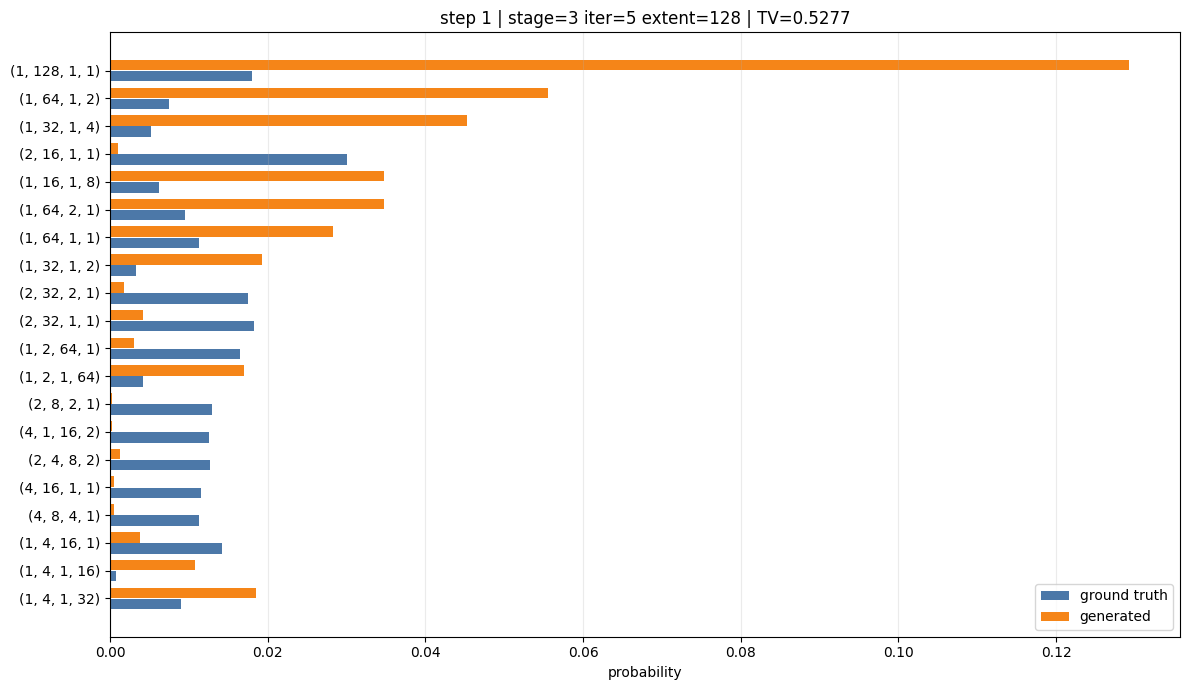

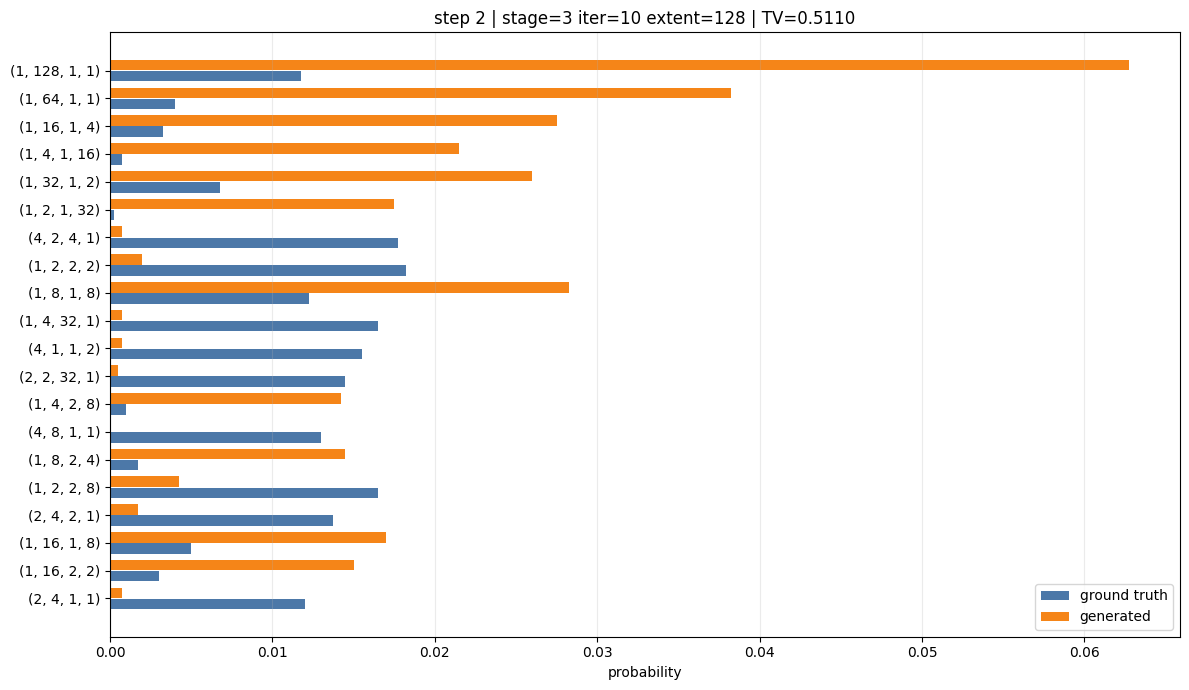

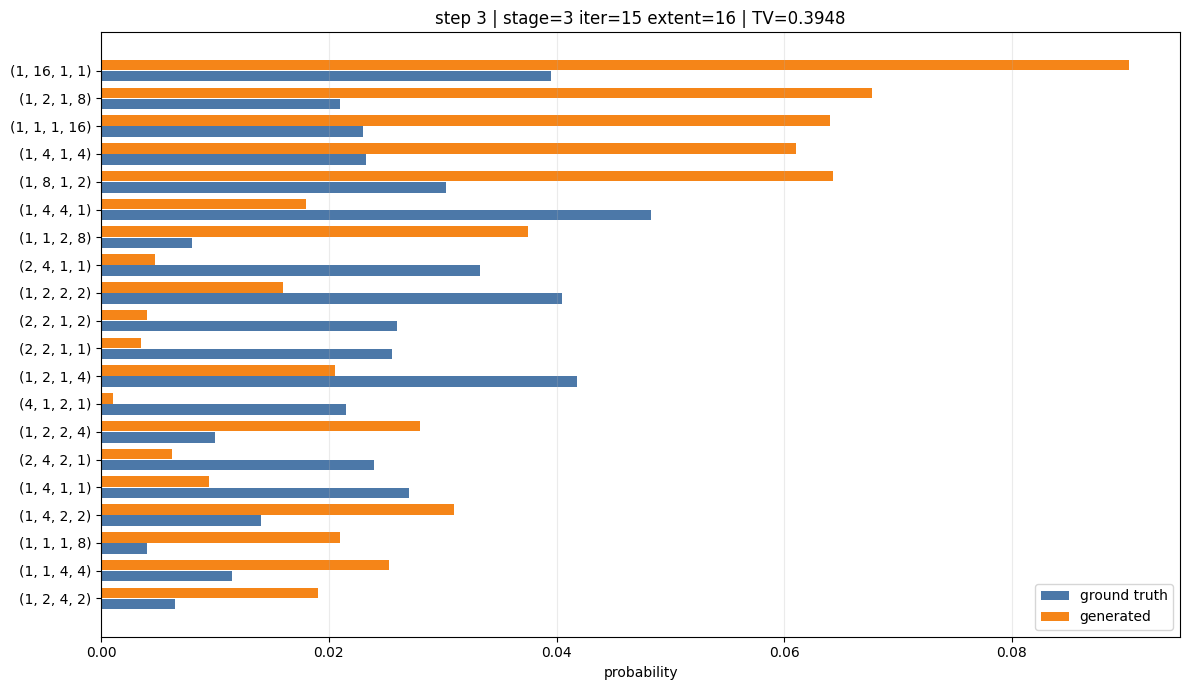

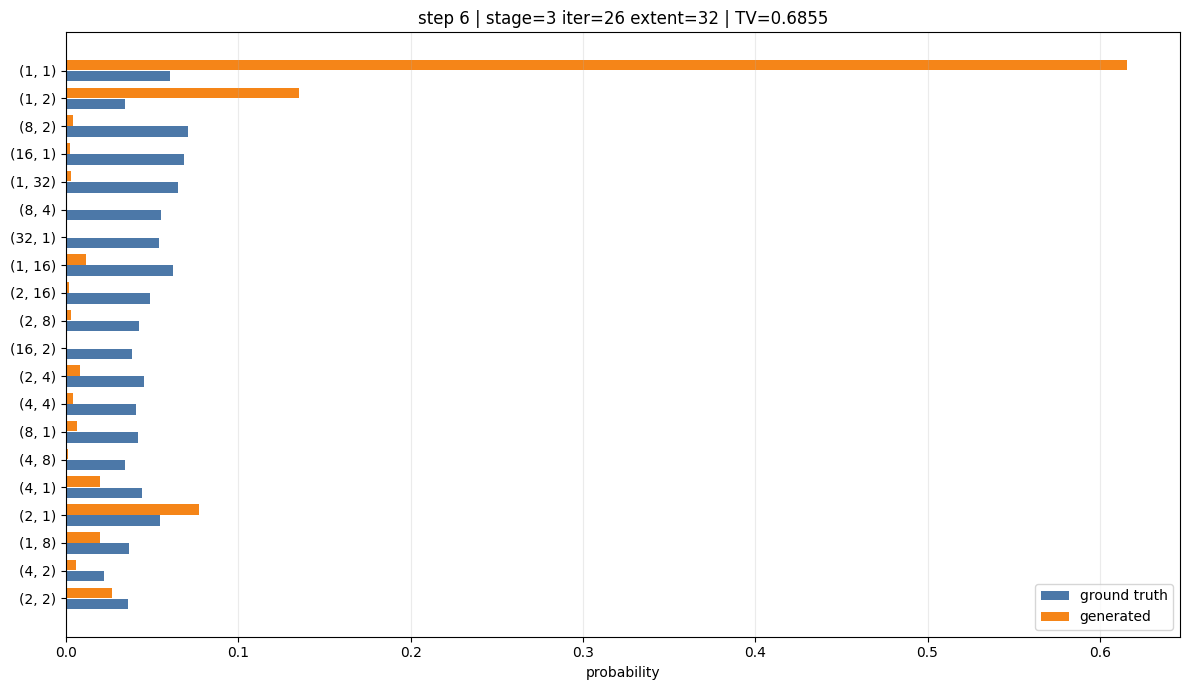

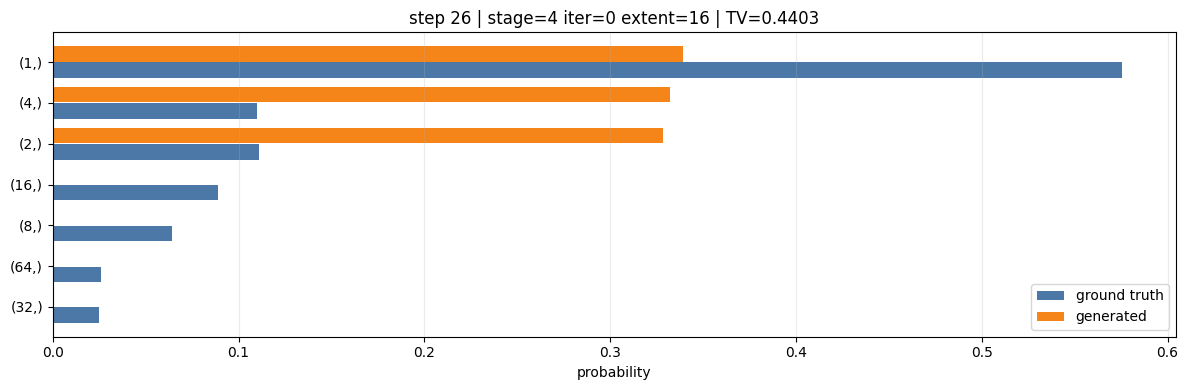

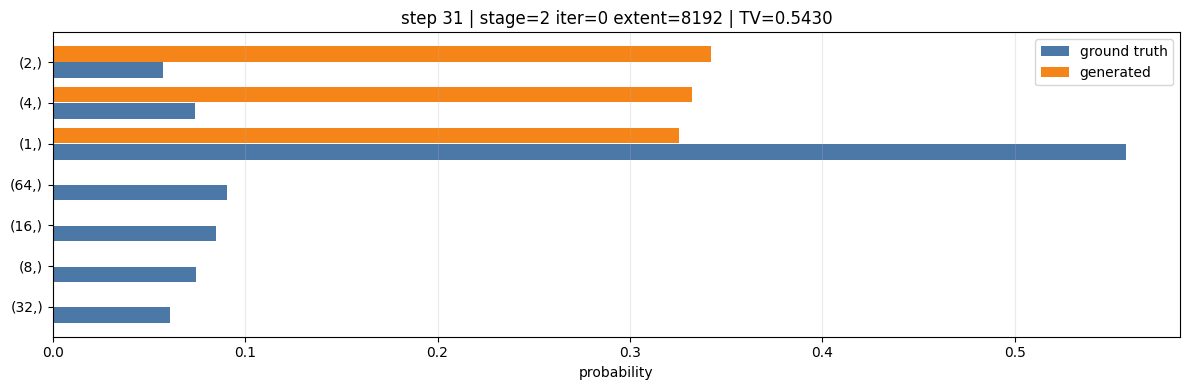

In [19]:
def plot_step_distribution(step_idx, top_k=20):
    df = top_table(step_idx, top_k=top_k).iloc[::-1]
    if df.empty:
        print(f'No split data for step {step_idx}')
        return

    meta = step_meta[step_idx]
    fig, ax = plt.subplots(figsize=(12, max(4, 0.35 * len(df))))
    y = range(len(df))
    ax.barh([i - 0.2 for i in y], df['gt_prob'], height=0.38, label='ground truth', color='#4c78a8')
    ax.barh([i + 0.2 for i in y], df['gen_prob'], height=0.38, label='generated', color='#f58518')
    ax.set_yticks(list(y))
    ax.set_yticklabels(df['family'])
    ax.set_xlabel('probability')
    ax.set_title(
        f'step {step_idx} | stage={meta["stage_id"]} iter={meta["iter_id"]} extent={meta["extent"]} '
        f'| TV={total_variation_distance(gt_counters.get(step_idx, Counter()), gen_counters.get(step_idx, Counter())):.4f}'
    )
    ax.legend()
    ax.grid(axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()


for step_idx in summary_df.loc[summary_df['gt_support'] > 1, 'step_idx']:
    plot_step_distribution(int(step_idx), top_k=20)

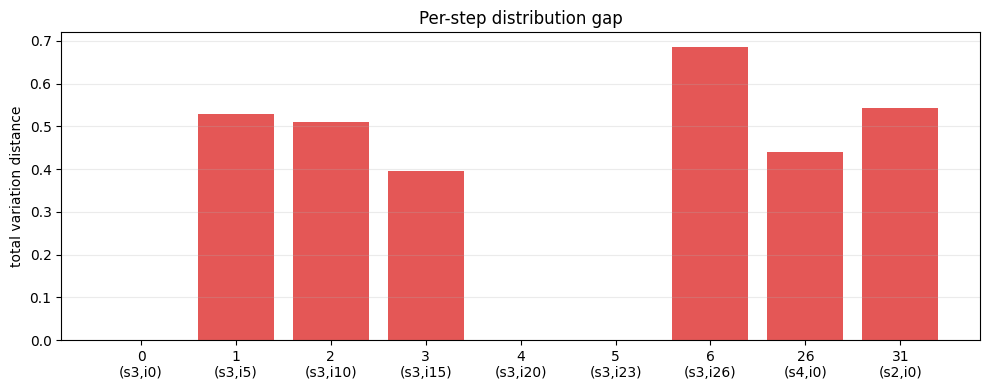

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_df = summary_df.copy()
plot_df['label'] = plot_df.apply(lambda row: f"{int(row['step_idx'])}\n(s{int(row['stage_id'])},i{int(row['iter_id'])})", axis=1)
ax.bar(plot_df['label'], plot_df['tv_distance'], color='#e45756')
ax.set_ylabel('total variation distance')
ax.set_title('Per-step distribution gap')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()